In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import leastsq

In [2]:
# Fluorescnece channel PSF ============================================================================

In [3]:
path = 'G:/OIDIC_SMLM_Scope_Yujin/PSF_sensitivity_flickering_characterization/20240726_PSF_test_objectiveS2/'
fn_xy = path + 'psf_xy.csv'
fn_xz = path + 'psf_xz.csv'

In [4]:
txy = pd.read_csv(fn_xy)
txz = pd.read_csv(fn_xz)
print(txy)

    Distance_(micrometer)  Gray_Value
0                       0    0.003466
1                       1    0.005319
2                       2    0.006668
3                       3    0.011419
4                       4    0.016841
5                       5    0.028129
6                       6    0.052710
7                       7    0.104805
8                       8    0.329148
9                       9    0.741835
10                     10    0.950645
11                     11    0.705671
12                     12    0.310732
13                     13    0.091365
14                     14    0.030247
15                     15    0.014583
16                     16    0.007554
17                     17    0.004285
18                     18    0.002456
19                     19    0.001643
20                     20    0.001220


In [5]:
xy = txy.to_numpy()
xz = txz.to_numpy()
xy

array([[0.00000e+00, 3.46600e-03],
       [1.00000e+00, 5.31900e-03],
       [2.00000e+00, 6.66800e-03],
       [3.00000e+00, 1.14190e-02],
       [4.00000e+00, 1.68410e-02],
       [5.00000e+00, 2.81290e-02],
       [6.00000e+00, 5.27100e-02],
       [7.00000e+00, 1.04805e-01],
       [8.00000e+00, 3.29148e-01],
       [9.00000e+00, 7.41835e-01],
       [1.00000e+01, 9.50645e-01],
       [1.10000e+01, 7.05671e-01],
       [1.20000e+01, 3.10732e-01],
       [1.30000e+01, 9.13650e-02],
       [1.40000e+01, 3.02470e-02],
       [1.50000e+01, 1.45830e-02],
       [1.60000e+01, 7.55400e-03],
       [1.70000e+01, 4.28500e-03],
       [1.80000e+01, 2.45600e-03],
       [1.90000e+01, 1.64300e-03],
       [2.00000e+01, 1.22000e-03]])

In [6]:
xy_x = xy[:,0] * 0.104
xy_y = xy[:,1]/np.max(xy[:,1])
xz_x = xz[:,0] * 0.02
xz_y = xz[:,1]/np.max(xz[:,1])
xz_x.shape

(116,)

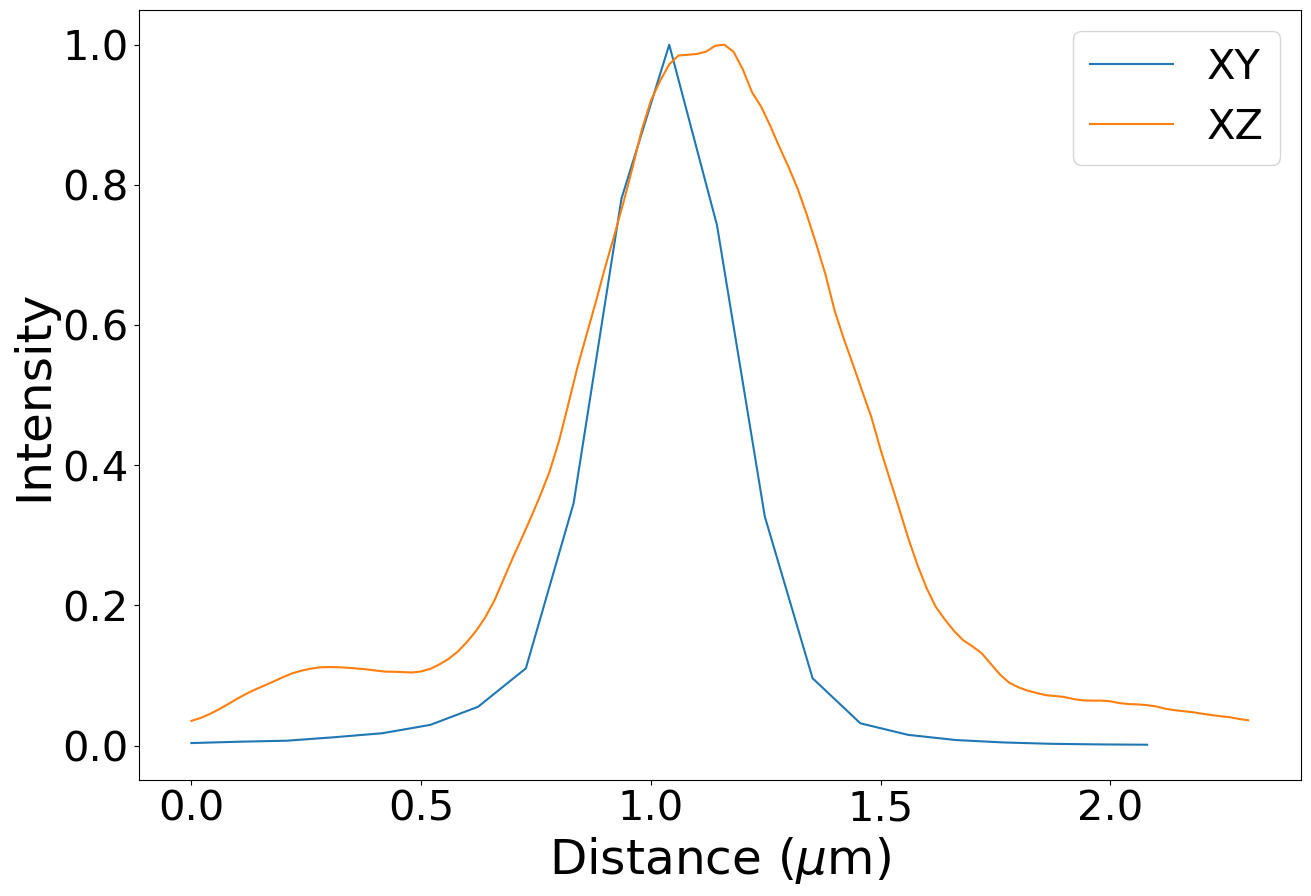

In [7]:
plt.figure(figsize=(15,10))
plt.plot(xy_x, xy_y, lw=1.5, label='XY')
plt.plot(xz_x, xz_y, lw=1.5, label='XZ')
plt.legend(prop={'size':30})
plt.xlabel('Distance ('r'$\mu$m)', fontsize=35)
plt.ylabel('Intensity', fontsize=35)
plt.rcParams.update({'font.size': 30})
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.show()

In [8]:
def gauss(x, p):
    A, x0, sig, b = p
    return A*np.exp(-(x-x0)**2/(2*sig**2))+b

def error(p, x, y):
    return gauss(x, p)-y

p01 = [0.999, 1.04, 0.104, 0.0013]
p02 = [0.9, 1.25, 0.2, 0.01]
fit1 = leastsq(error, p01, args=(xy_x, xy_y), full_output=1)
fit2 = leastsq(error, p02, args=(xz_x, xz_y), maxfev=10)

A1, x01, sig1, b1 = fit1[0]
A2, x02, sig2, b2 = fit2[0]

print(fit1[0])
print(fit2[0])

[0.98481243 1.03587192 0.14078919 0.01221642]
[0.94342148 1.13304241 0.24925294 0.06626839]


D:\Installation\Miniconda\envs\pyme\lib\site-packages\scipy\optimize\minpack.py:476: RuntimeWarning: Number of calls to function has reached maxfev = 10.
  warnings.warn(errors[info][0], RuntimeWarning)


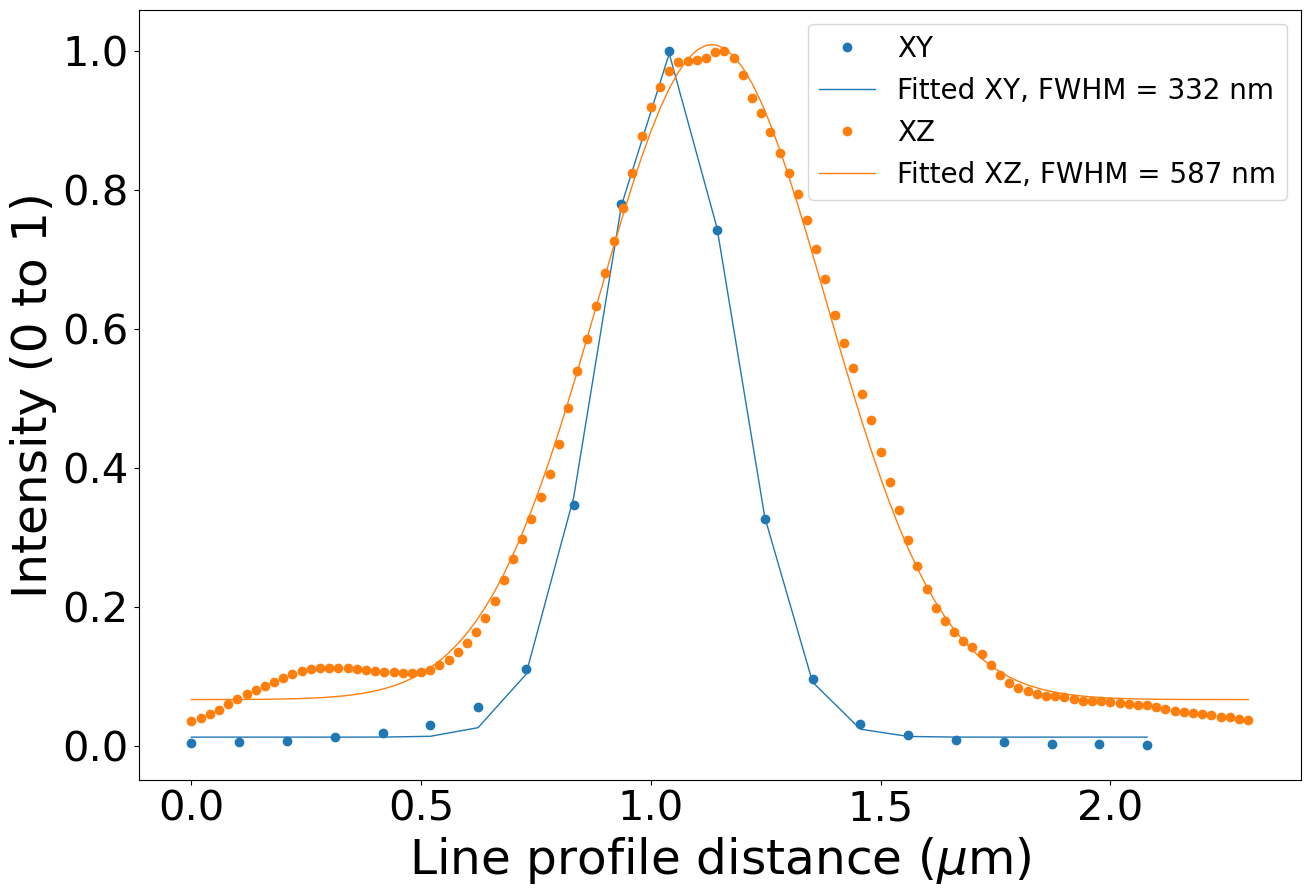

FWHM xy = 0.33155853849990846
FWHM xz = 0.5869906669904802


In [9]:
plt.figure(figsize=(15,10))
plt.plot(xy_x, xy_y, 'o', color=u'#1f77b4', lw=2, label='XY')
plt.plot(xy_x, A1*np.exp(-(xy_x-x01)**2/(2*sig1**2))+b1, color=u'#1f77b4', lw=1, label='Fitted XY, FWHM = 332 nm')
plt.plot(xz_x, xz_y, 'o', color=u'#ff7f0e', lw=2, label='XZ')
plt.plot(xz_x, A2*np.exp(-(xz_x-x02)**2/(2*sig2**2))+b2, color=u'#ff7f0e', lw=1, label='Fitted XZ, FWHM = 587 nm')
plt.legend(prop={'size':20})
plt.xlabel('Line profile distance ('r'$\mu$m)', fontsize=35)
plt.ylabel('Intensity (0 to 1)', fontsize=35)
plt.rcParams.update({'font.size': 30})
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.show()

print('FWHM xy =', 2.355*sig1)
print('FWHM xz =', 2.355*sig2)

In [10]:
# OI-DIC channel PSF ============================================================================

In [11]:
path = 'G:/OIDIC_SMLM_Scope_Yujin/PSF_sensitivity_flickering_characterization/20241025_oidicPSF_test/'
fn_xy = path + 'xy.csv'
fn_xz = path + 'xz.csv'
txy = pd.read_csv(fn_xy)
txz = pd.read_csv(fn_xz)
xy = txy.to_numpy()
xz = txz.to_numpy()
xy_x = xy[:,0] * 0.0645
xy_y = xy[:,1]/np.max(xy[:,1])
xz_x = xz[:,0] * 0.05
xz_y = xz[:,1]/np.max(xz[:,1])

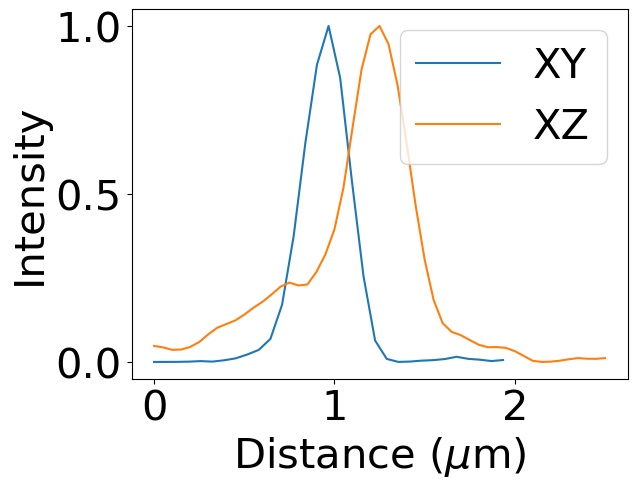

In [12]:
plt.plot(xy_x, xy_y, lw=1.5, label='XY')
plt.plot(xz_x, xz_y, lw=1.5, label='XZ')
plt.legend()
plt.xlabel('Distance ('r'$\mu$m)')
plt.ylabel('Intensity')
plt.show()

In [13]:
p03 = [0.999, 0.9, 0.104, 0.0013]
p04 = [0.9, 1.25, 0.2, 0.01]
fit3 = leastsq(error, p03, args=(xy_x, xy_y), full_output=1)
fit4 = leastsq(error, p04, args=(xz_x, xz_y), full_output=1)

A3, x03, sig3, b3 = fit3[0]
A4, x04, sig4, b4 = fit4[0]

print(fit3[0])
print(fit4[0])

[0.99093833 0.95463811 0.12633025 0.00426707]
[0.91462377 1.23373009 0.1703421  0.0692035 ]


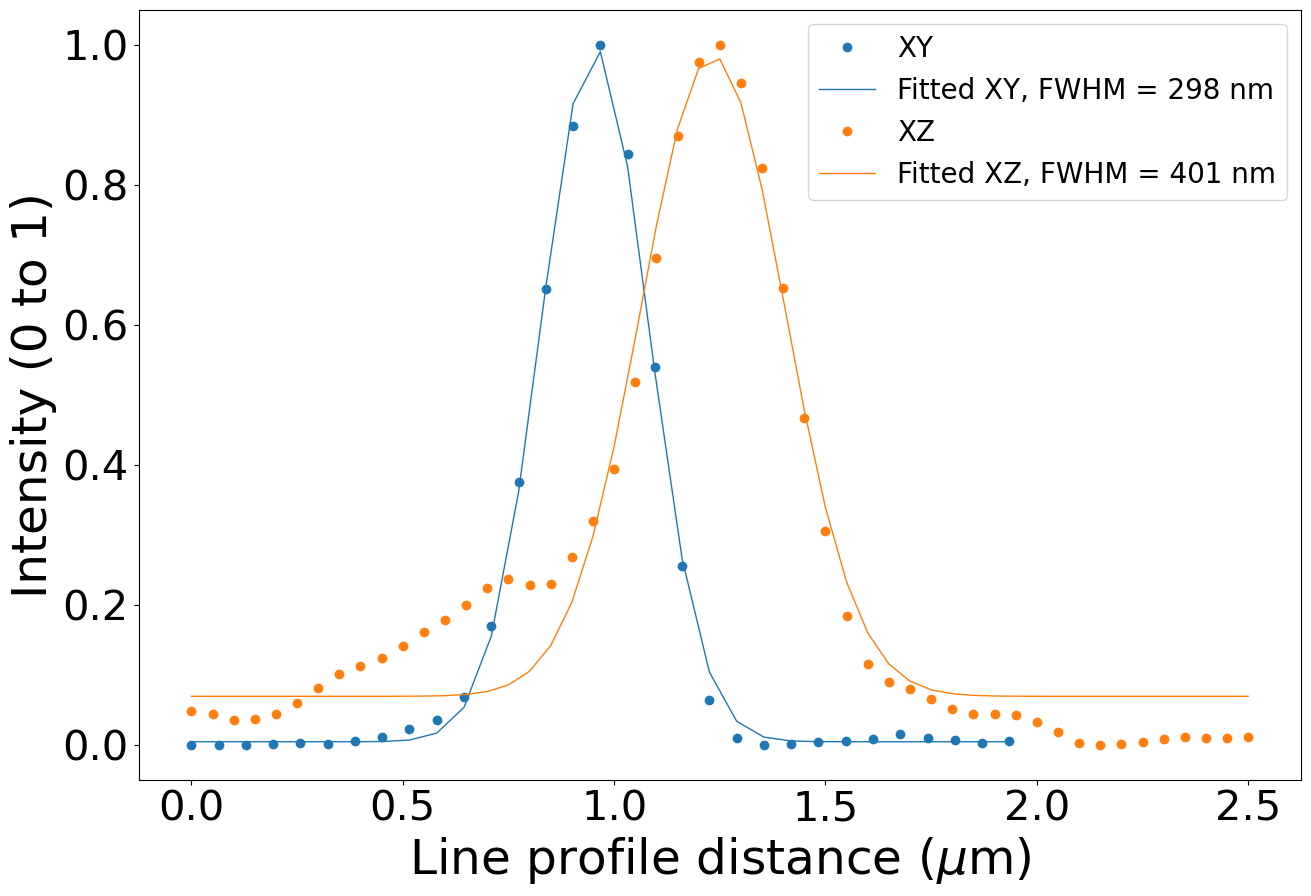

FWHM xy = 0.2975077429733275
FWHM xz = 0.40115564527102704


In [15]:
plt.figure(figsize=(15,10))
plt.plot(xy_x, xy_y, 'o', color=u'#1f77b4', lw=2, label='XY')
plt.plot(xy_x, A3*np.exp(-(xy_x-x03)**2/(2*sig3**2))+b3, color=u'#1f77b4', lw=1, label='Fitted XY, FWHM = 298 nm')
plt.plot(xz_x, xz_y, 'o', color=u'#ff7f0e', lw=2, label='XZ')
plt.plot(xz_x, A4*np.exp(-(xz_x-x04)**2/(2*sig4**2))+b4, color=u'#ff7f0e', lw=1, label='Fitted XZ, FWHM = 401 nm')
plt.legend(prop={'size':20})
plt.xlabel('Line profile distance ('r'$\mu$m)', fontsize=35)
plt.ylabel('Intensity (0 to 1)', fontsize=35)
plt.rcParams.update({'font.size': 30})
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.show()

print('FWHM xy =', 2.355*sig3)
print('FWHM xz =', 2.355*sig4)